In [1]:
from pathlib import Path

files = list(Path("/Users/goga/").rglob("streetfood_orders_dashboard.csv"))
files

[PosixPath('/Users/goga/Documents/GitHub/AI_Forecasting/data/IndiskSales2023_2025_BackUp/street food/street food/streetfood_orders_dashboard.csv')]

In [2]:
import pandas as pd

df = pd.read_csv(files[0])

print(df.shape)
print(df.columns.tolist())
display(df.head())

(153874, 17)
['day', 'month', 'year', 'date', 'time', 'orderNumber', 'totalAmount', 'paid', 'takeAway', 'foodName', 'category', 'quantity', 'price', 'source', 'location', 'time_only', 'timestamp']


,day,month,year,date,time,orderNumber,totalAmount,paid,takeAway,foodName,category,quantity,price,source,location,time_only,timestamp
0,Saturday,June,2023,2023-06-10,1900-01-01 11:24:02,1,60,Paid,Dine-in,Chicken Korma (Small Bowl),Curry Rice Bowl,1,60,POS_streetfood,streetfood,11:24:02,2023-06-10 11:24:02
1,Saturday,June,2023,2023-06-10,1900-01-01 11:24:11,2,60,Paid,Dine-in,Chicken Korma (Small Bowl),Curry Rice Bowl,1,60,POS_streetfood,streetfood,11:24:11,2023-06-10 11:24:11
2,Saturday,June,2023,2023-06-10,1900-01-01 11:28:11,3,120,Paid,Dine-in,Butter Chicken (Small Bowl),Curry Rice Bowl,2,60,POS_streetfood,streetfood,11:28:11,2023-06-10 11:28:11
3,Saturday,June,2023,2023-06-10,1900-01-01 11:29:00,4,120,Paid,Dine-in,Chicken Korma (Small Bowl),Curry Rice Bowl,2,60,POS_streetfood,streetfood,11:29:00,2023-06-10 11:29:00
4,Saturday,June,2023,2023-06-10,1900-01-01 11:29:14,5,60,Paid,Dine-in,Chicken Korma (Small Bowl),Curry Rice Bowl,1,60,POS_streetfood,streetfood,11:29:14,2023-06-10 11:29:14


## KPI - Sales by Channel / Order Type

### Business Question: How is total revenue distributed between Dine-in and TakeAway orders?

In [3]:
# Calculate total revenue by order type
revenue_by_channel = (
    df.groupby("takeAway")["totalAmount"]
    .sum()
    .reset_index()
)

revenue_by_channel.columns = ["Order Type", "Total Revenue"]

revenue_by_channel

,Order Type,Total Revenue
0,Dine-in,17366685
1,Takeaway,386973


## Diagram - Sales by Channel / Order Type

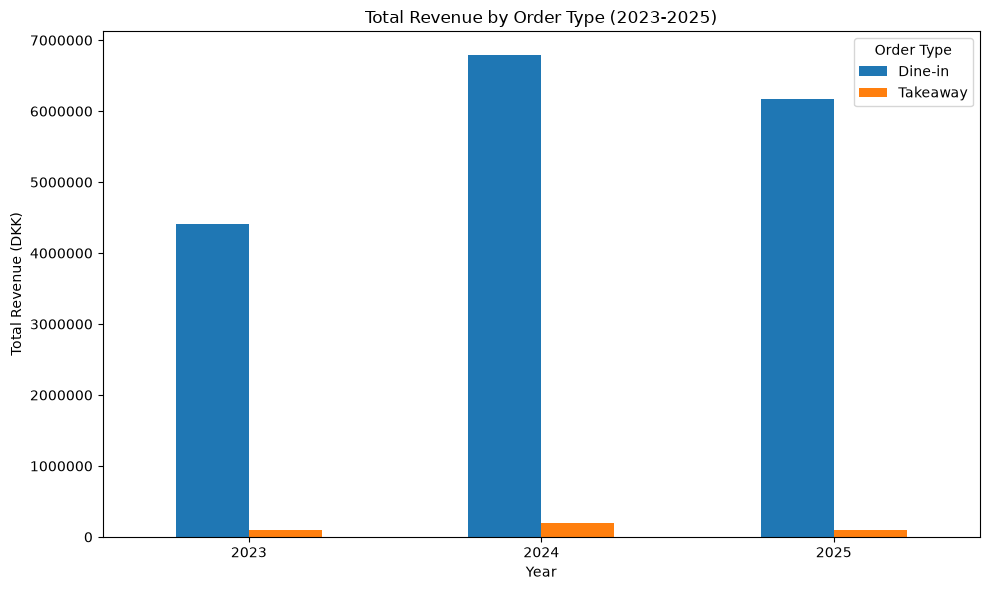

In [4]:
import matplotlib.pyplot as plt

# Calculate revenue by year and order type
revenue_channel_year = (
    df.groupby(["year", "takeAway"])["totalAmount"]
    .sum()
    .unstack(fill_value=0)
)

revenue_channel_year.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Total Revenue by Order Type (2023-2025)")
plt.xlabel("Year")
plt.ylabel("Total Revenue (DKK)")
plt.xticks(rotation=0)
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="Order Type")
plt.tight_layout()

plt.show()

In [5]:
# Calculate monthly revenue by order type
revenue_channel_month = (
    df.groupby(["year", "month", "takeAway"])["totalAmount"]
    .sum()
    .unstack(fill_value=0)
)

revenue_channel_month.head()

takeAway       Dine-in  Takeaway
year month                      
2023 August     845952     15065
     December   418084     11298
     July       980180     28025
     June       430780      6685
     November   472032     12155

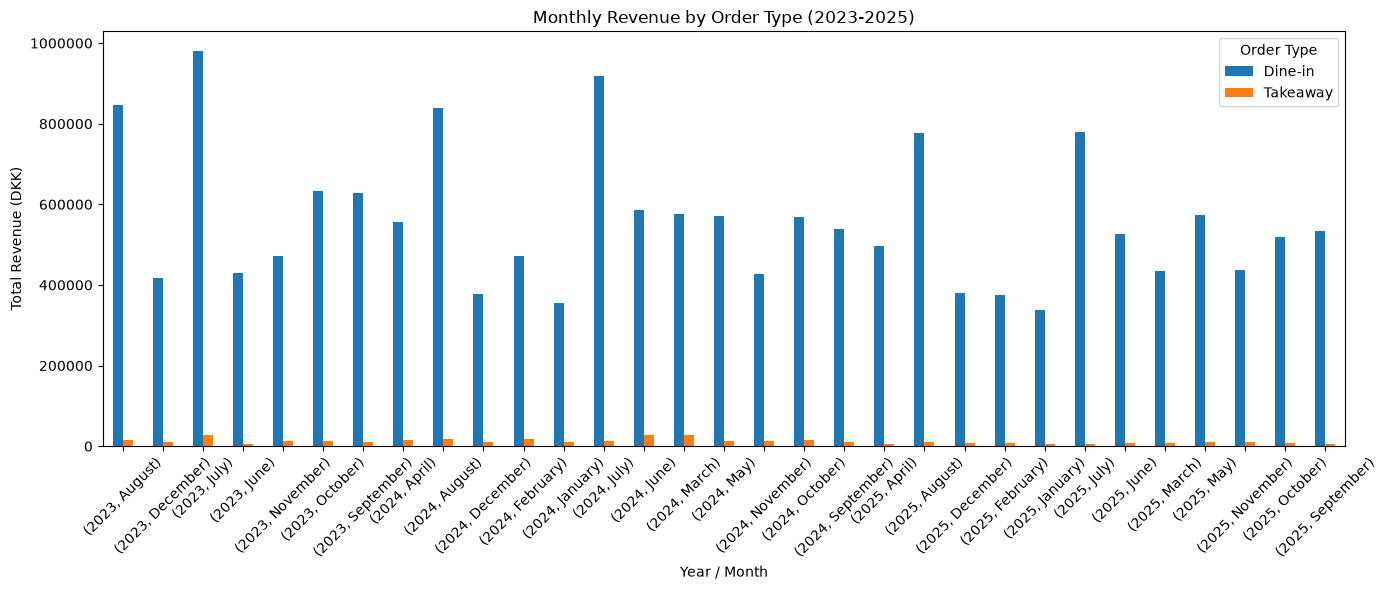

In [6]:
# Plot monthly revenue by order type
revenue_channel_month.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Monthly Revenue by Order Type (2023-2025)")
plt.xlabel("Year / Month")
plt.ylabel("Total Revenue (DKK)")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="Order Type")
plt.tight_layout()

plt.show()

In [7]:
# Calculate daily revenue by order type
revenue_channel_day = (
    df.groupby(["date", "takeAway"])["totalAmount"]
    .sum()
    .unstack(fill_value=0)
)

revenue_channel_day.head(10)

takeAway,Dine-in,Takeaway
date,,
2023-06-10,26295,275
2023-06-11,21280,475
2023-06-12,16090,325
2023-06-13,20180,85
2023-06-14,20185,480
2023-06-15,18325,250
2023-06-16,26215,205
2023-06-17,20235,335
2023-06-18,12460,85


## KPI - Sales by Daypart

### Business Question: Which part of the day generates the most revenue?

In [8]:
# Create hour column from time
df["hour"] = pd.to_datetime(df["time"], format="mixed").dt.hour

In [9]:
# Create daypart categories
df["daypart"] = df["hour"].apply(
    lambda x: "Lunch" if 11 <= x <= 15 else "Dinner"
)

# Calculate revenue by year and daypart
revenue_daypart = (
    df.groupby(["year", "daypart"])["totalAmount"]
    .sum()
    .unstack(fill_value=0)
)

revenue_daypart

daypart,Dinner,Lunch
year,,
2023,4007013,499542
2024,6167796,812821
2025,5501120,765366


## Diagram - sales by Daypart

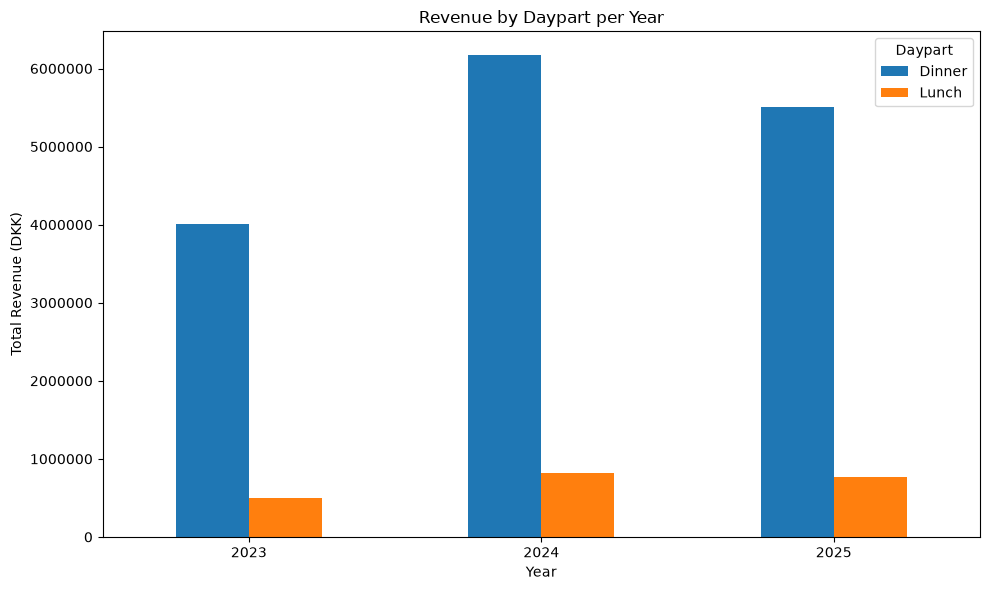

In [10]:
# Plot revenue by daypart per year
revenue_daypart.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Revenue by Daypart per Year")
plt.xlabel("Year")
plt.ylabel("Total Revenue (DKK)")
plt.xticks(rotation=0)
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="Daypart")
plt.tight_layout()

plt.show()

In [11]:
# Calculate daily revenue by daypart 
revenue_daypart_day = (
    df.groupby(["date", "daypart"])["totalAmount"]
    .sum()
    .unstack(fill_value=0)
)

revenue_daypart_day.head(10)

daypart,Dinner,Lunch
date,,
2023-06-10,23855,2715
2023-06-11,20850,905
2023-06-12,14175,2240
2023-06-13,18805,1460
2023-06-14,19805,860
2023-06-15,14645,3930
2023-06-16,24745,1675
2023-06-17,18070,2500
2023-06-18,11565,980


# KPI - Revenue by Category

### Busines Question: Which product categories generate the most revenue?

In [12]:
df["product_revenue"] = df["quantity"] * df["price"]


In [13]:
# Calculate total revenue by category
revenue_category = (
    df.groupby(["category", "year"])["product_revenue"]
    .sum()
    .unstack(fill_value=0)
)
display(revenue_category)

year,2023,2024,2025
category,,,
Curry Rice Bowl,1720940,2988535,2863342
Indian Plate,621400,712825,452620
Side,264326,426432,407189


## Diagram - Revenue by Category

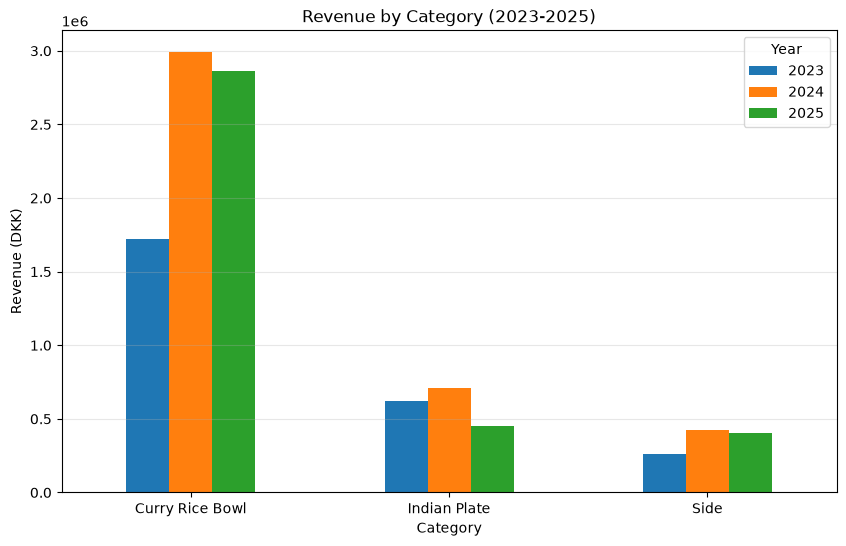

In [14]:
revenue_category.plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Revenue by Category (2023-2025)")
plt.xlabel("Category")
plt.ylabel("Revenue (DKK)")
plt.xticks(rotation=0)
plt.legend(title="Year")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [15]:
# Calculate daily revenue by category
revenue_category_day = (
    df.groupby(["date", "category"])["product_revenue"]
    .sum()
    .unstack(fill_value=0)
)

revenue_category_day.head(10)

category,Curry Rice Bowl,Indian Plate,Side
date,,,
2023-06-10,10345,3495,1655
2023-06-11,6890,3275,1525
2023-06-12,6315,1475,1005
2023-06-13,7325,2415,1045
2023-06-14,6245,3575,1370
2023-06-15,7740,1395,1135
2023-06-16,10025,2845,1515
2023-06-17,9530,3340,1155
2023-06-18,5190,1330,695


## KPI - Average Orders per Day

### Business Question: What is the average number of orders per day?

In [16]:
# Count unique orders per day
daily_orders = (
    df.groupby(["year", "date"])["orderNumber"]
      .nunique()
      .reset_index(name="orders")
)

# Calculate average orders per day for each year
avg_orders_per_day = (
    daily_orders.groupby("year")["orders"]
    .mean()
    .reset_index(name="average_orders_per_day")
)

avg_orders_per_day

,year,average_orders_per_day
0,2023,130.447761
1,2024,115.711911
2,2025,106.749304


## Diagram - Average Orders per Day

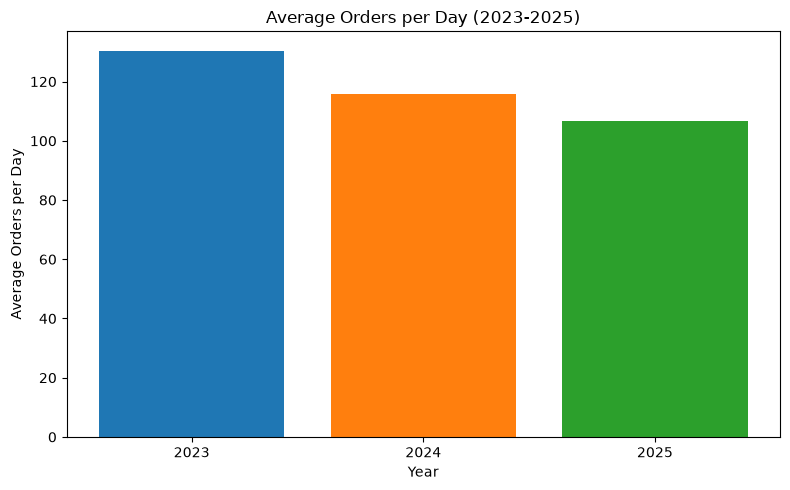

In [17]:
plt.figure(figsize=(8, 5))

plt.bar(
    avg_orders_per_day["year"].astype(str),
    avg_orders_per_day["average_orders_per_day"],
    color=["tab:blue", "tab:orange", "tab:green"]
)

plt.title("Average Orders per Day (2023-2025)")
plt.xlabel("Year")
plt.ylabel("Average Orders per Day")
plt.tight_layout()

plt.show()

# Business KPI Dashboard 

### Restaurant Performance Overview

In [18]:
# Make sure date column is datetime
df["date"] = pd.to_datetime(df["date"])

print("Available date range:")
print(df["date"].min(), "to", df["date"].max())

Available date range:
2023-06-10 00:00:00 to 2025-12-30 00:00:00


In [19]:
import ipywidgets as widgets
from IPython.display import display

# Date range selectors
start_date = widgets.DatePicker(
    description="Start date:",
    value=df["date"].min().date()
)

end_date = widgets.DatePicker(
    description="End date:",
    value=df["date"].max().date()
)

display(start_date, end_date)

DatePicker(value=datetime.date(2023, 6, 10), description='Start date:', step=1)

DatePicker(value=datetime.date(2025, 12, 30), description='End date:', step=1)

In [20]:
# Filter data based on selected date range
def filter_data():
    start = pd.to_datetime(start_date.value)
    end = pd.to_datetime(end_date.value)

    filtered_df = df[
        (df["date"] >= start) &
        (df["date"] <= end)
    ].copy()

    return filtered_df

In [ ]:
update_button = widgets.Button(
    description="Update Dashboard",
    button_style="primary"
)

dashboard_output = widgets.Output()

display(update_button, dashboard_output)

Button(button_style='primary', description='Update Dashboard', style=ButtonStyle())

Output()

In [22]:
from matplotlib.ticker import FuncFormatter

milllions = FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M")
def update_dashboard(b):
    with dashboard_output:
        dashboard_output.clear_output(wait=True)

        filtered_df, sales_channel, sales_daypart, revenue_category, avg_orders = get_dashboard_data()

        fig, axes = plt.subplots(2, 2, figsize=(14, 9))

         # KPI 1 - Sales by Channel / Order Type
        sales_channel.plot(
            kind="bar",
            ax=axes[0, 0],
            color=["steelblue", "orange"]
        )
        axes[0, 0].set_title("Sales by Channel / Order Type")
        axes[0, 0].set_xlabel("Order Type")
        axes[0, 0].set_ylabel("Revenue (DKK)")
        axes[0,0].yaxis.set_major_formatter(milllions)
        axes[0, 0].tick_params(axis="x", rotation=0)

        # KPI 2 - Sales by Daypart
        sales_daypart.plot(
            kind="bar",
            ax=axes[0, 1],
            color=["steelblue", "orange"]
        )
        axes[0, 1].set_title("Sales by Daypart")
        axes[0, 1].set_xlabel("Daypart")
        axes[0, 1].set_ylabel("Revenue (DKK)")
        axes[0,1].yaxis.set_major_formatter(milllions)
        axes[0, 1].tick_params(axis="x", rotation=0)

        # KPI 3 - Revenue by Category
        revenue_category.plot(
            kind="bar",
            ax=axes[1, 0],
            color=["steelblue", "orange", "green"]
        )

        axes[1, 0].set_title("Revenue by Category")
        axes[1, 0].set_xlabel("Category")
        axes[1, 0].set_ylabel("Revenue (DKK)")
        axes[1,0].yaxis.set_major_formatter(milllions)
        axes[1, 0].tick_params(axis="x", rotation=0)

        # KPI 4 - Average Orders per Day
        axes[1, 1].axis("off")
        axes[1, 1].text(
            0.5, 0.60,
            "Average Orders per Day",
            ha="center",
            fontsize=14,
            fontweight="bold"
        )

        axes[1, 1].text(
            0.5, 0.43,
            f"{avg_orders:.1f}",
            ha="center",
            fontsize=24,
            fontweight="bold"
        )

        fig.suptitle(
            "Restaurant Performance Overview",
            fontsize=18,
            fontweight="bold"
        )
        plt.tight_layout()
        plt.show()

update_button.on_click(update_dashboard)


In [23]:
# KPI 1 - Sales by Channel / Order Type

def calculate_sales_by_channel(filtered_df):

    sales_channel = (
        filtered_df
        .groupby("takeAway")["totalAmount"]
        .sum()
    )

    return sales_channel

In [24]:
# KPI 2 - Sales by Daypart

def calculate_sales_by_daypart(filtered_df):

    sales_daypart = (
        filtered_df
        .groupby("daypart")["totalAmount"]
        .sum()
    )
    return sales_daypart

In [25]:
# Recreate hour and daypart columns
df["hour"] = pd.to_datetime(df["time"], format="mixed").dt.hour

df["daypart"] = df["hour"].apply(
    lambda x: "Lunch" if 11 <= x <= 15 else "Dinner"
)

In [26]:
# Recreate product revenue
df["product_revenue"] = df["quantity"] * df["price"]

In [27]:
# KPI 3 - Revenue by Category

def calculate_revenue_by_category(filtered_df):

    revenue_category = (
        filtered_df
        .groupby("category")["product_revenue"]
        .sum()
        .sort_values(ascending=False)
    )

    return revenue_category

In [28]:
# KPI 4 - Average Orders per Day

def calculate_avg_orders_per_day(filtered_df):

    daily_orders = (
        filtered_df
        .groupby("date")["orderNumber"]
        .nunique()
    )

    avg_orders_per_day = daily_orders.mean()

    return avg_orders_per_day

In [29]:
# Build dashboard data from selected date range

def get_dashboard_data():
    filtered_df = filter_data()

    sales_channel = calculate_sales_by_channel(filtered_df)
    sales_daypart = calculate_sales_by_daypart(filtered_df)
    revenue_category = calculate_revenue_by_category(filtered_df)
    avg_orders = calculate_avg_orders_per_day(filtered_df)

    return filtered_df, sales_channel, sales_daypart, revenue_category, avg_orders

In [30]:
from IPython.display import HTML, display

def show_avg_orders_card(avg_orders):
    display(HTML(f"""
    <div style="
        padding: 20px;
        border-radius: 12px;
        text-align: center;
        width: 250px;
        box_shadow: 0 2px 8px rgba(0,0,0,0.15);
        margin: 10px;
    ">
        <h3>Average Orders per Day</h3>
        <h1>{avg_orders:.1f}</h1>
    </div>
    """))    

In [31]:
import matplotlib.pyplot as plt

def plot_sales_by_channel(sales_channel):
    plt.figure(figsize=(7, 4))

    sales_channel.plot(
        kind="bar",
        color=["steelblue", "orange"]
    )

    plt.title("Sales by Channel / Order Type")
    plt.xlabel("Order Type")
    plt.ylabel("Revenue (DKK)")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [32]:
def plot_sales_by_daypart(sales_daypart):
    plt.figure(figsize=(7, 4))

    sales_daypart.plot(
        kind="bar",
        color=["steelblue", "orange"]
    )

    plt.title("Sales by Daypart")
    plt.xlabel("Daypart")
    plt.ylabel("Revenue (DKK)")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [33]:
def plot_revenue_by_category(revenue_category):
    plt.figure(figsize=(7, 4))

    revenue_category.plot(
        kind="bar",
        color=["steelblue", "orange", "green"]
    )

    plt.title("Revenue by Category")
    plt.xlabel("Category")
    plt.ylabel("Revenue (DKK)")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()